# Aim: Fit sim data to omnicron wave 

- Recover 'true burden' and fit linear models if possible

In [4]:
import pandas as pd
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import matplotlib.dates as mdates
#print(smf)
import covasim as cv

print(cv.__file__)
print(hasattr(cv, "Sim"))
print(cv.Sim)

/storage/hcraddock/GitHub/covasim4wastewater/covasim/__init__.py
True
<class 'covasim.sim.Sim'>


In [36]:
import optuna

In [37]:
print(optuna.__version__)

5.0.0


## Data
- Load pre-saved data

In [5]:
OUT = Path.home() / "GitHub" / "covasim_fit_data"     # same folder you saved to

df_pl_weekly = pd.read_pickle(OUT / "df_cases_weekly_pl.pkl")

print(df_pl_weekly.shape)             # expect (102, 8)
#print(df_pl_weekly.columns.tolist())  # week_number, week_start, week_end, n_days, n_distinct_values, weekly_total, week_mid, weekly_total_per_100k
#print(df_pl_weekly.dtypes)            # week_start, week_end, week_mid should be datetime64
df_pl_weekly.head()

(102, 8)


,week_number,week_start,week_end,n_days,n_distinct_values,weekly_total,week_mid,weekly_total_per_100k
0,1,2021-06-30,2021-07-06,7,1,792.0,2021-07-03,37.426105
1,2,2021-07-07,2021-07-13,7,1,1394.0,2021-07-10,65.873725
2,3,2021-07-14,2021-07-20,7,1,2157.0,2021-07-17,101.929429
3,4,2021-07-21,2021-07-27,7,1,3626.0,2021-07-24,171.347293
4,5,2021-07-28,2021-08-03,7,1,4613.0,2021-07-31,217.988158


In [6]:
df_pl_weekly.head()

,week_number,week_start,week_end,n_days,n_distinct_values,weekly_total,week_mid,weekly_total_per_100k
0,1,2021-06-30,2021-07-06,7,1,792.0,2021-07-03,37.426105
1,2,2021-07-07,2021-07-13,7,1,1394.0,2021-07-10,65.873725
2,3,2021-07-14,2021-07-20,7,1,2157.0,2021-07-17,101.929429
3,4,2021-07-21,2021-07-27,7,1,3626.0,2021-07-24,171.347293
4,5,2021-07-28,2021-08-03,7,1,4613.0,2021-07-31,217.988158


In [8]:
df_pl_ww = pd.read_pickle(OUT / "df_ww_pl.pkl")
print(df_pl_ww.dtypes)   
df_pl_ww.head()

Sample_Date                 object
Mean viral gene copies/L     int64
dtype: object


,Sample_Date,Mean viral gene copies/L
0,2/24/21,681730
1,2/28/21,943877
2,3/1/21,1034196
3,3/3/21,1918221
4,3/7/21,770022


In [9]:
#Rename
df_pl_ww = df_pl_ww.rename(columns={"Mean viral gene copies/L": "ww_copies_per_L"})

In [10]:
## Convert to date-type
df_pl_ww["Sample_Date"] = pd.to_datetime(df_pl_ww["Sample_Date"], format="%m/%d/%y")

In [11]:
print(df_pl_ww["Sample_Date"].dtype)

datetime64[ns]


#### Plot

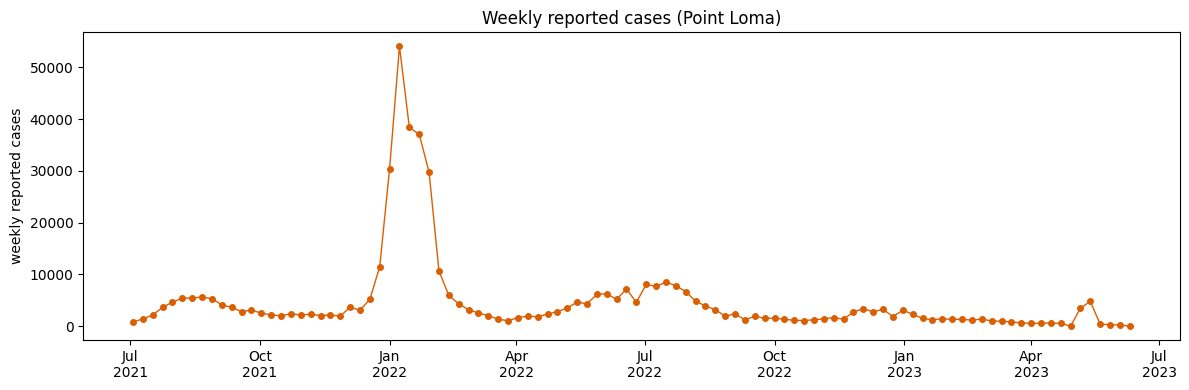

In [12]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df_pl_weekly["week_mid"], df_pl_weekly["weekly_total"], "o-", ms=4, lw=1, color="#D95F02")

ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=range(1, 13, 3)))   # Jan, Apr, Jul, Oct
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))

ax.set_ylabel("weekly reported cases")
ax.set_title("Weekly reported cases (Point Loma)")
plt.tight_layout()
plt.show()

## 2. Omicron Wave

#### I. Case data (omicron)

In [13]:
FIT_START = pd.Timestamp("2021-10-01")
FIT_END   = pd.Timestamp("2022-04-30")

df_omc = df_pl_weekly[(df_pl_weekly["week_start"] >= FIT_START) &
                        (df_pl_weekly["week_end"] <= FIT_END)].copy()

print(len(df_omc), "weeks in the window")
print(df_omc["n_distinct_values"].value_counts())   # mostly 1s; a run of 2s means the grid is drifting

29 weeks in the window
n_distinct_values
1    21
2     6
3     2
Name: count, dtype: int64


In [14]:
df_omc.head()

,week_number,week_start,week_end,n_days,n_distinct_values,weekly_total,week_mid,weekly_total_per_100k
14,15,2021-10-06,2021-10-12,7,1,2156.0,2021-10-09,101.882174
15,16,2021-10-13,2021-10-19,7,1,2002.0,2021-10-16,94.604876
16,17,2021-10-20,2021-10-26,7,1,2385.0,2021-10-23,112.703611
17,18,2021-10-27,2021-11-02,7,1,2155.0,2021-10-30,101.834919
18,19,2021-11-03,2021-11-09,7,1,2293.0,2021-11-06,108.356134


#### II. Waste-water data (omicron)

In [15]:
# Rebuild the window so ww_omc picks up the new name
ww_omc = df_pl_ww[(df_pl_ww["Sample_Date"] >= FIT_START) &
                  (df_pl_ww["Sample_Date"] <= FIT_END)].copy()

In [38]:
ww_omc.head()

,Sample_Date,ww_copies_per_L
87,2021-10-04,248673
88,2021-10-06,218099
89,2021-10-10,248399
90,2021-10-11,409576
91,2021-10-13,653372


In [17]:
print(len(ww_omc), "wastewater samples in the window")

88 wastewater samples in the window


In [18]:
print(ww_omc["Sample_Date"].min().date(), ww_omc["Sample_Date"].max().date())
print(ww_omc["Sample_Date"].diff().dt.days.value_counts().sort_index())

2021-10-04 2022-04-27
Sample_Date
1.0    42
2.0    14
3.0     2
4.0    19
5.0     8
6.0     1
7.0     1
Name: count, dtype: int64


In [19]:
gaps = ww_omc["Sample_Date"].diff().dt.days
long_gaps = ww_omc.loc[gaps >= 5, "Sample_Date"].dt.date
print(long_gaps.tolist())

[datetime.date(2021, 11, 8), datetime.date(2021, 11, 14), datetime.date(2021, 11, 27), datetime.date(2022, 1, 4), datetime.date(2022, 1, 31), datetime.date(2022, 2, 7), datetime.date(2022, 3, 13), datetime.date(2022, 3, 28), datetime.date(2022, 4, 3), datetime.date(2022, 4, 24)]


### Plot

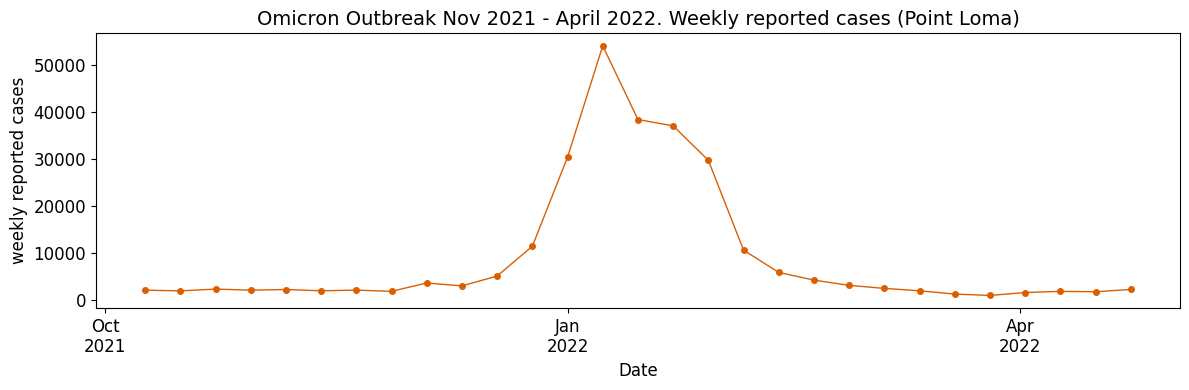

In [20]:

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df_omc["week_mid"], df_omc["weekly_total"], "o-", ms=4, lw=1, color="#D95F02")

ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=range(1, 13, 3)))   # Jan, Apr, Jul, Oct
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))

ax.set_ylabel("weekly reported cases", fontsize=12)
ax.set_xlabel("Date", fontsize=12)
ax.set_title("Omicron Outbreak Nov 2021 - April 2022. Weekly reported cases (Point Loma)", fontsize=14)
ax.tick_params(axis="both", labelsize=12)

plt.tight_layout()
plt.show()

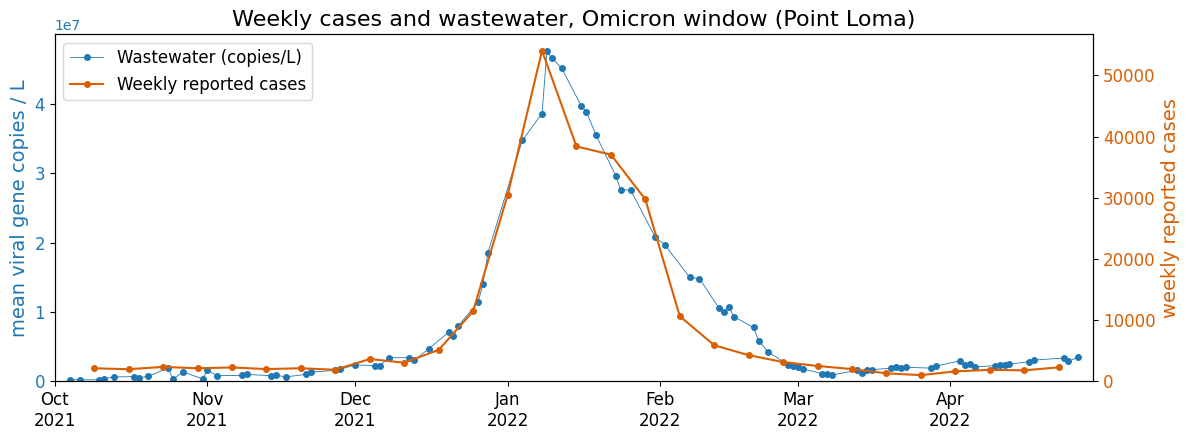

In [21]:
fig, ax = plt.subplots(figsize=(12, 4.5))

# Left axis: wastewater
c_ww = "tab:blue"
l1, = ax.plot(ww_omc["Sample_Date"], ww_omc["ww_copies_per_L"], ".-", ms=8, lw=0.6,
              color=c_ww, label="Wastewater (copies/L)")
ax.set_ylabel("mean viral gene copies / L", color=c_ww, fontsize=14)
ax.tick_params(axis="y", labelcolor=c_ww, labelsize=12)
ax.set_ylim(bottom=0)

# Right axis: weekly cases, plotted at the middle of each week
ax2 = ax.twinx()
c_cases = "#D95F02"
l2, = ax2.plot(df_omc["week_mid"], df_omc["weekly_total"], "o-", ms=4, lw=1.5,
               color=c_cases, label="Weekly reported cases")
ax2.set_ylabel("weekly reported cases", color=c_cases, fontsize=14)
ax2.tick_params(axis="y", labelcolor=c_cases, labelsize=12)
ax2.set_ylim(bottom=0)

ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))
ax.tick_params(axis="x", labelsize=12)
ax.set_xlim(FIT_START, FIT_END)

ax.set_title("Weekly cases and wastewater, Omicron window (Point Loma)", fontsize=16)
ax.legend(handles=[l1, l2], loc="upper left", fontsize=12)
plt.tight_layout()
plt.show()

In [38]:
df_pl_weekly.head()

,week_number,week_start,week_end,n_days,n_distinct_values,weekly_total,week_mid,weekly_total_per_100k
0,1,2021-06-30,2021-07-06,7,1,792.0,2021-07-03,37.426105
1,2,2021-07-07,2021-07-13,7,1,1394.0,2021-07-10,65.873725
2,3,2021-07-14,2021-07-20,7,1,2157.0,2021-07-17,101.929429
3,4,2021-07-21,2021-07-27,7,1,3626.0,2021-07-24,171.347293
4,5,2021-07-28,2021-08-03,7,1,4613.0,2021-07-31,217.988158


In [29]:
df_omc.head()

,week_number,week_start,week_end,n_days,n_distinct_values,weekly_total,week_mid,weekly_total_per_100k
14,15,2021-10-06,2021-10-12,7,1,2156.0,2021-10-09,101.882174
15,16,2021-10-13,2021-10-19,7,1,2002.0,2021-10-16,94.604876
16,17,2021-10-20,2021-10-26,7,1,2385.0,2021-10-23,112.703611
17,18,2021-10-27,2021-11-02,7,1,2155.0,2021-10-30,101.834919
18,19,2021-11-03,2021-11-09,7,1,2293.0,2021-11-06,108.356134


# Part 2: Covasim Simulation + fitting wave

In [25]:
#Get catchment population
CATCHMENT_POP = 2116170

AGENT_POP_SIZE  = 50_000
POP_SCALE = CATCHMENT_POP / AGENT_POP_SIZE

#Start date 
SIM_START = pd.Timestamp("2021-11-20")     # start near the end of the flat baseline

In [26]:
ASCERTAINMENT = 0.3      # assumed: 30% of infections get reported
DURATION      = 12       # rough days from infection to recovery in Covasim

# reported cases per day around the sim start (week containing SIM_START)
row = df_omc[df_omc["week_end"] >= SIM_START].iloc[0]
cases_per_day = row["weekly_total"] / 7

active_real = cases_per_day / ASCERTAINMENT * DURATION
POP_INFECTED = int(round(active_real / POP_SCALE))
print(f"{cases_per_day:.0f} reported/day -> ~{active_real:,.0f} active infections -> {POP_INFECTED} agents")

309 reported/day -> ~12,354 active infections -> 292 agents


In [ ]:
#### Testing
testing = cv.test_prob(
    symp_prob=0.10,        # daily probability a symptomatic person is tested
    asymp_prob=0.001,      # daily probability an asymptomatic person is tested
    symp_quar_prob=0.10,
    asymp_quar_prob=0.001,
    test_delay=1,
)

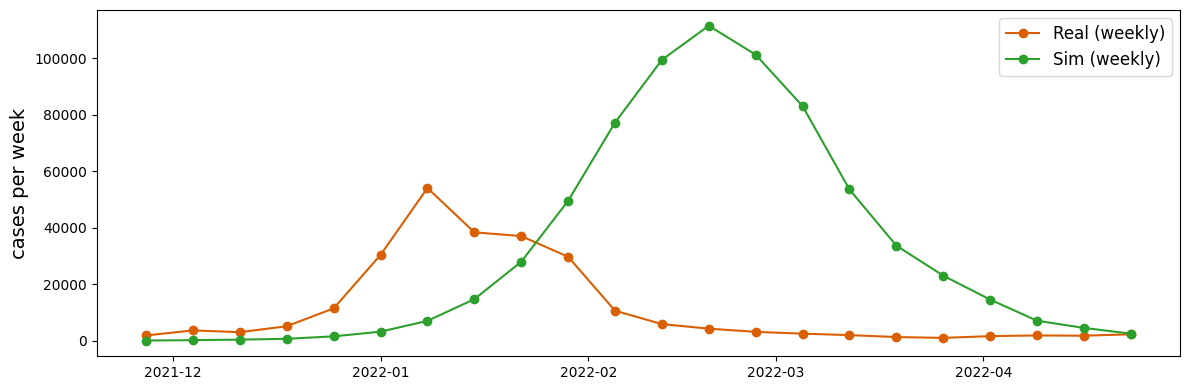

In [ ]:
sim = cv.Sim(
    pop_size=POP_SIZE,
    pop_scale=POP_SCALE,
    pop_type='hybrid',
    location='usa',
    pop_infected=POP_INFECTED,      # 292
    n_imports=0,
    start_day=SIM_START,
    end_day=FIT_END,
    interventions=[testing],
    verbose=0,
)
sim.run()

sim_daily = pd.Series(sim.results["new_diagnoses"].values,
                      index=pd.to_datetime(sim.datevec))

df_cmp = df_omc[df_omc["week_start"] >= SIM_START].copy()
df_cmp["sim_weekly_total"] = [sim_daily.loc[s:e].sum()
                              for s, e in zip(df_cmp["week_start"], df_cmp["week_end"])]

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df_cmp["week_mid"], df_cmp["weekly_total"], "o-", color="#D95F02", label="Real (weekly)")
ax.plot(df_cmp["week_mid"], df_cmp["sim_weekly_total"], "o-", color="tab:green", label="Sim (weekly)")
ax.set_ylabel("cases per week", fontsize=14)
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()

In [46]:
def run_sim(beta, symp_prob, pop_infected, rel_sus=1.0, seed=0):
    testing = cv.test_prob(symp_prob=symp_prob, asymp_prob=0.001,
                           symp_quar_prob=symp_prob, asymp_quar_prob=0.001, test_delay=1)
    s = cv.Sim(pop_size=POP_SIZE, pop_scale=POP_SCALE, pop_type='hybrid', location='usa',
               beta=beta, pop_infected=pop_infected, n_imports=0,
               start_day=SIM_START, end_day=FIT_END, interventions=[testing],
               rand_seed=seed, verbose=0)
    s.run()
    return s

def weekly_sim(s, weeks):
    daily = pd.Series(s.results["new_diagnoses"].values, index=pd.to_datetime(s.datevec))
    return [daily.loc[a:b].sum() for a, b in zip(weeks["week_start"], weeks["week_end"])]

s = run_sim(beta=0.025, symp_prob=0.05, pop_infected=POP_INFECTED)
df_cmp["sim_weekly_total"] = weekly_sim(s, df_cmp)

## Plot

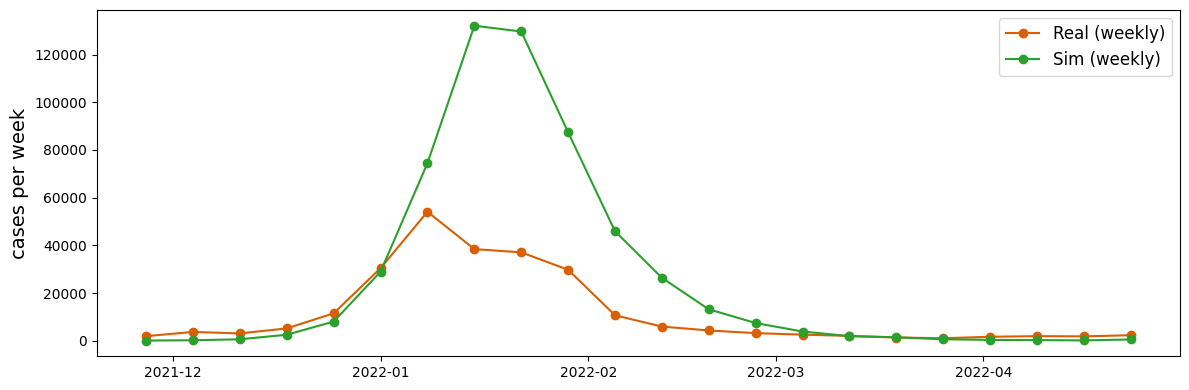

In [47]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df_cmp["week_mid"], df_cmp["weekly_total"], "o-", color="#D95F02", label="Real (weekly)")
ax.plot(df_cmp["week_mid"], df_cmp["sim_weekly_total"], "o-", color="tab:green", label="Sim (weekly)")
ax.set_ylabel("cases per week", fontsize=14)
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()

## Function - Simulate Outbreak

In [44]:
# Observed weekly cases: original df_omc, restricted to weeks the sim covers
df_fit = df_omc[df_omc["week_start"] >= SIM_START].reset_index(drop=True)
cases_obs = df_fit["weekly_total"].values

# Observed wastewater: original ww_omc, same restriction
ww_fit = (ww_omc[ww_omc["Sample_Date"] >= SIM_START]
            .set_index("Sample_Date")["ww_copies_per_L"].sort_index())

print(len(cases_obs), "weekly points;", df_fit["week_start"].min().date(), "to", df_fit["week_end"].max().date())
print(len(ww_fit), "wastewater points")

22 weekly points; 2021-11-24 to 2022-04-26
69 wastewater points


In [30]:
df_cmp = df_omc[df_omc["week_start"] >= SIM_START].copy()

In [ ]:
#Get catchment population
CATCHMENT_POP = 2116170

AGENT_POP_SIZE  = 50_000
POP_SCALE = CATCHMENT_POP / AGENT_POP_SIZE

#Start date 
SIM_START = pd.Timestamp("2021-11-20")     # start near the end of the flat baseline

In [ ]:
ASCERTAINMENT = 0.3      # assumed: 30% of infections get reported
DURATION      = 12       # rough days from infection to recovery in Covasim

# reported cases per day around the sim start (week containing SIM_START)
row = df_omc[df_omc["week_end"] >= SIM_START].iloc[0]
cases_per_day = row["weekly_total"] / 7

active_real = cases_per_day / ASCERTAINMENT * DURATION
POP_INFECTED = int(round(active_real / POP_SCALE))
print(f"{cases_per_day:.0f} reported/day -> ~{active_real:,.0f} active infections -> {POP_INFECTED} agents")

In [ ]:
#Testing
testing = cv.test_prob(
    symp_prob=0.10,        # daily probability a symptomatic person is tested
    asymp_prob=0.001,      # daily probability an asymptomatic person is tested
    symp_quar_prob=0.10,
    asymp_quar_prob=0.001,
    test_delay=1,
)

In [27]:
def run_sim(beta, symp_prob, pop_infected, rel_sus=1.0, seed=0):
    """Run one Covasim sim for San Diego (Point Loma) and return it.

    beta         : transmission rate per contact. Higher = faster growth, earlier and taller wave.
    symp_prob    : daily probability a symptomatic person gets tested (and so becomes a reported case).
                   Higher = more reported cases for the same number of infections.
    pop_infected : number of AGENTS infected on day 1 (each represents POP_SCALE real people).
    rel_sus      : relative susceptibility, 1.0 = fully susceptible. Lower values mimic prior
                   immunity (vaccination / earlier infection), giving a smaller, shorter wave.
    seed         : random seed. Different seeds give different stochastic runs of the same setup.
    """
    # Testing intervention: controls how many infections turn into reported cases (new_diagnoses)
    testing = cv.test_prob(
        symp_prob=symp_prob,         # symptomatic people tested per day (fitted)
        asymp_prob=0.001,            # asymptomatic people tested per day (fixed, assumed)
        symp_quar_prob=symp_prob,    # symptomatic people in quarantine tested per day (tied to symp_prob)
        asymp_quar_prob=0.001,       # asymptomatic people in quarantine tested per day (fixed, assumed)
        test_delay=1,                # days between a test and its result
    )

    s = cv.Sim(
        pop_size=POP_SIZE,           # number of simulated agents
        pop_scale=POP_SCALE,         # real people per agent, so outputs are in real-people units
        pop_type='hybrid',           # contact network type
        location='usa',              # age structure and demographics
        beta=beta,
        pop_infected=pop_infected,
        n_imports=0,                 # no new infections arriving from outside
        start_day=SIM_START,         # first day of the sim
        end_day=FIT_END,             # last day of the sim
        interventions=[testing],
        rand_seed=seed,
        verbose=0,
    )

    # Apply relative susceptibility to every agent before running
    s.initialize()
    s.people.rel_sus[:] *= rel_sus

    s.run()
    return s


def weekly_sim(s, weeks):
    """Sum the sim's daily new_diagnoses over each reporting week.

    s     : a finished sim
    weeks : table with week_start and week_end columns (one row per week)
    Returns a list of simulated weekly case totals, one per row of `weeks`.
    """
    daily = pd.Series(s.results["new_diagnoses"].values,
                      index=pd.to_datetime(s.datevec))
    return [daily.loc[a:b].sum() for a, b in zip(weeks["week_start"], weeks["week_end"])]




### Run

In [31]:
# Test run with the manual guess
s = run_sim(beta=0.025, symp_prob=0.05, pop_infected=POP_INFECTED, rel_sus=1.0)
df_cmp["sim_weekly_total"] = weekly_sim(s, df_cmp)

#### Plot

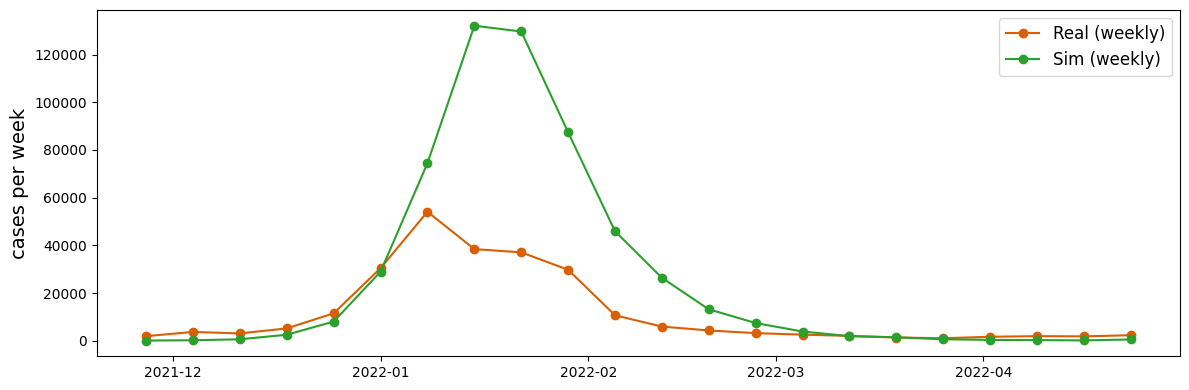

In [32]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df_cmp["week_mid"], df_cmp["weekly_total"], "o-", color="#D95F02", label="Real (weekly)")
ax.plot(df_cmp["week_mid"], df_cmp["sim_weekly_total"], "o-", color="tab:green", label="Sim (weekly)")
ax.set_ylabel("cases per week", fontsize=14)
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()

#### Run 2: Change relative susceptibility

In [33]:
# Test run with the manual guess
s = run_sim(beta=0.025, symp_prob=0.05, pop_infected=POP_INFECTED, rel_sus=0.5)
df_cmp["sim_weekly_total"] = weekly_sim(s, df_cmp)

#### Other Outbreak outputs

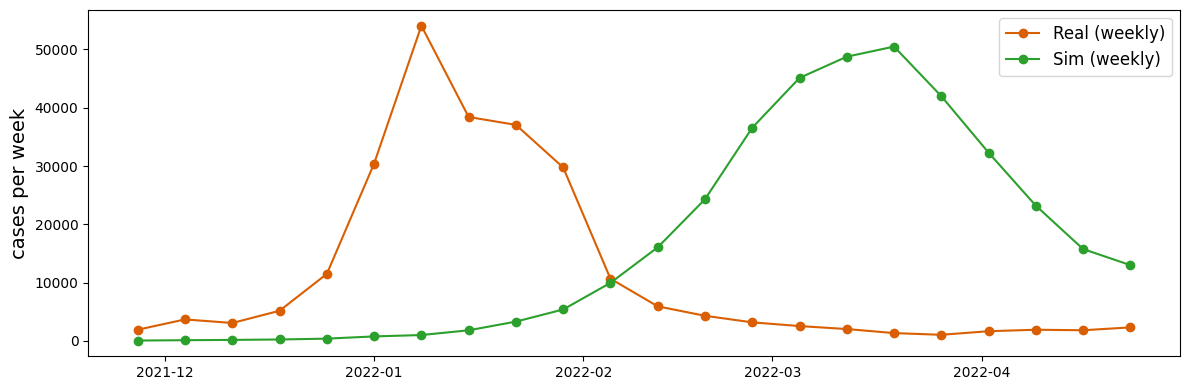

In [34]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df_cmp["week_mid"], df_cmp["weekly_total"], "o-", color="#D95F02", label="Real (weekly)")
ax.plot(df_cmp["week_mid"], df_cmp["sim_weekly_total"], "o-", color="tab:green", label="Sim (weekly)")
ax.set_ylabel("cases per week", fontsize=14)
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
total_diagnosed = s.results["cum_diagnoses"][-1]
total_infected  = s.results["cum_infections"][-1]
print(f"implied ascertainment: {total_diagnosed / total_infected:.2f}")

## Part 3: Optuna

In [43]:
df_cmp.head(2)

,week_number,week_start,week_end,n_days,n_distinct_values,weekly_total,week_mid,weekly_total_per_100k,sim_weekly_total
21,22,2021-11-24,2021-11-30,7,1,1911.0,2021-11-27,90.304654,50.0
22,23,2021-12-01,2021-12-07,7,1,3673.0,2021-12-04,173.568286,107.0


In [40]:
df_omc.head(2)

,week_number,week_start,week_end,n_days,n_distinct_values,weekly_total,week_mid,weekly_total_per_100k
14,15,2021-10-06,2021-10-12,7,1,2156.0,2021-10-09,101.882174
15,16,2021-10-13,2021-10-19,7,1,2002.0,2021-10-16,94.604876


In [42]:
ww_omc.head(2)

,Sample_Date,ww_copies_per_L
87,2021-10-04,248673
88,2021-10-06,218099


In [ ]:


# ---- Observed data (both start at SIM_START, when the sim starts) ----
ww_fit = (ww_omc[ww_omc["Sample_Date"] >= SIM_START]
            .set_index("Sample_Date")["ww_copies_per_L"].sort_index())
cases_obs = df_cmp["weekly_total"].values

In [46]:
N_SEEDS = 3          # sims averaged per trial (reduces stochastic noise)
W_WW    = 1.0        # weight of the wastewater term relative to the cases term

In [ ]:
# ---- Run several seeds, return averaged weekly cases and wastewater as date-indexed Series ----
def sim_outputs(beta, symp_prob, pop_infected, n_seeds=N_SEEDS):
    """Run n_seeds stochastic sims at one parameter setting and average them.

    beta         : transmission rate (from Optuna)
    symp_prob    : daily probability a symptomatic person is tested (from Optuna)
    pop_infected : agents infected on day 1 (from Optuna)
    n_seeds      : how many random seeds to average (reduces sim noise)

    Returns (sim_wk, sim_ww): Series with the same indexes as cases_obs and ww_fit.
    """
    wk, ww = [], []   # one Series per seed

    for seed in range(n_seeds):
        s = run_sim(beta=beta, symp_prob=symp_prob,
                    pop_infected=pop_infected,
                    rel_sus=1.0,                      # fixed: fully susceptible (not fitted)
                    seed=seed)

        # Weekly sim cases, labelled with the same week_mid dates as cases_obs
        wk.append(pd.Series(weekly_sim(s, df_fit), index=cases_obs.index))

        d = extract_wastewater_regression_data(s)     # assumes columns 'date' and 'wastewater'
        d["date"] = pd.to_datetime(d["date"])
        # Sim wastewater, kept only on days with a real sample (index = ww_fit dates)
        ww.append(d.set_index("date")["wastewater"].reindex(ww_fit.index))

    # Average across seeds; result keeps the date index
    sim_wk = pd.concat(wk, axis=1).mean(axis=1)
    sim_ww = pd.concat(ww, axis=1).mean(axis=1)
    return sim_wk, sim_ww


# ---- Loss ----
def compute_loss(sim_wk, sim_ww):
    """Compare sim to real data. Lower = better fit.

    sim_wk : Series of sim weekly cases (index = week_mid dates)
    sim_ww : Series of sim wastewater (index = real sample dates)
    Uses globals cases_obs and ww_fit.
    """
    # Align by date so the two series can't be silently misordered
    sim_wk, obs_wk = sim_wk.align(cases_obs, join="inner")
    sim_w,  obs_w  = sim_ww.align(ww_fit,   join="inner")

    # Cases: absolute level matters (symp_prob sets the reporting fraction)
    loss_c = np.sqrt(np.mean((np.log1p(sim_wk) - np.log1p(obs_wk)) ** 2))

    # Wastewater: shape and timing only. Subtracting the mean log-difference
    # removes the unknown scale factor (std of the residual).
    eps = 1e-3 * sim_w.max() + 1e-12                  # tiny offset so log() never sees zero
    r = np.log(sim_w + eps) - np.log(obs_w)           # log-difference per sample date
    r = r[np.isfinite(r)]
    loss_w = r.std(ddof=0)                            # ddof=0 matches np.std
    return loss_c, loss_w


# ---- Optuna objective ----
def objective(trial):
    """One Optuna trial: pick parameters, run sims, return the loss to minimise."""
    beta         = trial.suggest_float("beta", 0.015, 0.06)
    symp_prob    = trial.suggest_float("symp_prob", 0.01, 0.3, log=True)
    pop_infected = trial.suggest_int("pop_infected", 100, 900)

    sim_wk, sim_ww = sim_outputs(beta, symp_prob, pop_infected)

    if sim_wk.sum() < 1 or sim_ww.notna().sum() == 0 or sim_ww.max() <= 0:
        return 10.0                                   # outbreak fizzled: heavy penalty

    loss_c, loss_w = compute_loss(sim_wk, sim_ww)
    trial.set_user_attr("loss_cases", float(loss_c))
    trial.set_user_attr("loss_ww", float(loss_w))
    return loss_c + W_WW * loss_w

In [60]:
"""
Extract daily (burden, cases, wastewater) time series from a Covasim
simulation, ready for the cases-only / wastewater-only / both linear-model
comparison.

Mapping used:
    burden     -> new_infections   (true, unobserved disease burden)
    cases      -> new_diagnoses    (observed via testing/surveillance)
    wastewater -> sum of viral_shedding_hist across agents, per day

IMPORTANT: `new_diagnoses` will be all zeros unless the sim includes a
testing intervention (e.g. cv.test_prob or cv.test_num). Add one if you
want non-trivial "cases" data.
"""

def extract_wastewater_regression_data(sim) -> pd.DataFrame:
    """
    Parameters
    ----------
    sim : covasim.Sim
        A Sim object that has already been run (sim.run()).

    Returns
    -------
    pd.DataFrame with columns: day, date, burden, cases, wastewater
    """
    results = sim.results

    # --- True burden ------------------------------------------------------
    burden = np.asarray(results['new_infections'].values, dtype=float)

    # --- Case data ----------------------------------------------------------
    if 'new_diagnoses' not in results:
        raise KeyError("sim.results has no 'new_diagnoses' — did the sim run?")
    cases = np.asarray(results['new_diagnoses'].values, dtype=float)
    if cases.sum() == 0:
        print("Warning: 'cases' (new_diagnoses) is all zero. "
              "Add a testing intervention, e.g. cv.test_prob(...), to the sim.")

    # --- Wastewater signal ------------------------------------------------
    viral_shedding_hist = np.asarray(results['viral_shedding_hist'])  # (n_people, n_days)
    wastewater = viral_shedding_hist.sum(axis=0)

    n = len(burden)
    df = pd.DataFrame({
        'day': np.arange(n),
        'date': [sim.date(d) for d in range(n)],
        'burden': burden,
        'cases': cases,
        'wastewater': wastewater[:n],
    })
    return df

#### Data

In [53]:
# ---- Re-initiate the observed data (both are date-indexed Series) ----
SIM_START = pd.Timestamp("2021-11-20")   # first day of the sim

df_fit = df_omc[df_omc["week_start"] >= SIM_START].reset_index(drop=True)

# Weekly cases, indexed by the middle date of each reporting week
cases_obs = df_fit.set_index("week_mid")["weekly_total"].astype(float)

# Wastewater, indexed by sample date
ww_fit = (ww_omc[ww_omc["Sample_Date"] >= SIM_START]
            .set_index("Sample_Date")["ww_copies_per_L"].sort_index())

# ---- Verify ----
print(type(cases_obs).__name__, len(cases_obs), cases_obs.index.min().date(), "to", cases_obs.index.max().date())
print(type(ww_fit).__name__, len(ww_fit), ww_fit.index.min().date(), "to", ww_fit.index.max().date())

Series 22 2021-11-27 to 2022-04-23
Series 69 2021-11-21 to 2022-04-27


In [62]:
ww_fit = ww_fit[ww_fit.index >= SIM_START + pd.Timedelta(days=7)]

In [54]:
assert len(cases_obs) == len(df_fit)
assert (df_fit["n_days"] == 7).all()
assert df_fit["week_end"].max() <= FIT_END
assert ww_fit.notna().all() and (ww_fit > 0).all()
print("OK")

OK


In [52]:
print(type(cases_obs), type(ww_fit), type(df_fit))

<class 'numpy.ndarray'> <class 'pandas.core.series.Series'> <class 'pandas.core.frame.DataFrame'>


#### Test

In [61]:
# 1. Before the study: run the pipeline once by hand, so errors show with a clear traceback
sim_wk, sim_ww = sim_outputs(beta=0.025, symp_prob=0.05, pop_infected=POP_INFECTED, n_seeds=1)
print(sim_wk.head(3))
print(sim_ww.head(3))
print("NaNs in sim_ww:", sim_ww.isna().sum(), "of", len(sim_ww))   # expect 0
print(compute_loss(sim_wk, sim_ww))                                  # (loss_cases, loss_ww)

week_mid
2021-11-27     68.000000
2021-12-04    174.440000
2021-12-11    601.751023
dtype: float64
Sample_Date
2021-11-21    8.673266e+04
2021-11-22    1.259056e+06
2021-11-27    1.815537e+07
dtype: float32
NaNs in sim_ww: 0 of 69
(1.5170640904170418, 1.1543776912249826)


In [63]:
study = optuna.create_study(direction="minimize",
                            sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=5, show_progress_bar=True)
print(study.best_params, study.best_value)
print(study.best_trial.user_attrs)
print(study.trials_dataframe()[["number", "value", "params_beta", "params_symp_prob", "params_pop_infected", "duration"]])

[I 2026-10-01 12:25:29,787] A new study created in memory with name: no-name-c3beeef2-d8fc-4e1e-bbe9-c485d380da2b


  0%|          | 0/5 [00:00<?, ?it/s]

[I 2026-10-01 12:25:51,074] Trial 0 finished with value: 2.6510421188203552 and parameters: {'beta': 0.024363502971184062, 'symp_prob': 0.2536999076681772, 'pop_infected': 686}. Best is trial 0 with value: 2.6510421188203552.
[I 2026-10-01 12:26:12,287] Trial 1 finished with value: 2.6415489396071843 and parameters: {'beta': 0.029966462104925914, 'symp_prob': 0.01700037298921102, 'pop_infected': 224}. Best is trial 1 with value: 2.6415489396071843.
[I 2026-10-01 12:26:32,881] Trial 2 finished with value: 3.4390049125554487 and parameters: {'beta': 0.016452090304204987, 'symp_prob': 0.19030368381735815, 'pop_infected': 581}. Best is trial 1 with value: 2.6415489396071843.
[I 2026-10-01 12:26:54,270] Trial 3 finished with value: 2.716802114233288 and parameters: {'beta': 0.03270181444490114, 'symp_prob': 0.010725209743171997, 'pop_infected': 876}. Best is trial 1 with value: 2.6415489396071843.
[I 2026-10-01 12:27:15,570] Trial 4 finished with value: 2.3165314315843073 and parameters: {'

### Run

In [64]:
study.optimize(objective, n_trials=100, show_progress_bar=True)

print(study.best_params, study.best_value)
print(study.best_trial.user_attrs)

  0%|          | 0/100 [00:00<?, ?it/s]

[I 2026-10-01 12:31:34,112] Trial 5 finished with value: 2.6266284398975466 and parameters: {'beta': 0.019585112746335846, 'symp_prob': 0.028145092716060652, 'pop_infected': 520}. Best is trial 4 with value: 2.3165314315843073.
[I 2026-10-01 12:31:55,245] Trial 6 finished with value: 2.6933025576362075 and parameters: {'beta': 0.025798625466052896, 'symp_prob': 0.02692655251486473, 'pop_infected': 590}. Best is trial 4 with value: 2.3165314315843073.
[I 2026-10-01 12:32:16,195] Trial 7 finished with value: 3.1249760010627377 and parameters: {'beta': 0.018487346516301045, 'symp_prob': 0.027010527749605478, 'pop_infected': 393}. Best is trial 4 with value: 2.3165314315843073.
[I 2026-10-01 12:32:37,303] Trial 8 finished with value: 2.7960909631422726 and parameters: {'beta': 0.0264017496054259, 'symp_prob': 0.14447746112718687, 'pop_infected': 259}. Best is trial 4 with value: 2.3165314315843073.
[I 2026-10-01 12:32:58,387] Trial 9 finished with value: 2.9411648043374816 and parameters: 

### Plot

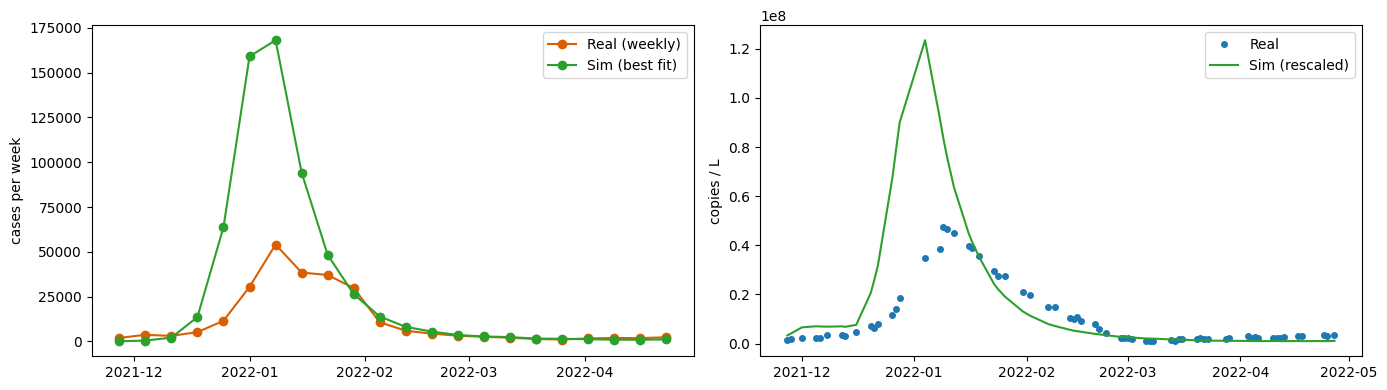

In [65]:
bp = study.best_params
sim_wk, sim_ww = sim_outputs(bp["beta"], bp["symp_prob"], bp["pop_infected"], n_seeds=5)

eps = 1e-3 * sim_ww.max() + 1e-12
scale = np.exp(np.mean(np.log(ww_fit.values) - np.log(sim_ww.values + eps)))

fig, ax = plt.subplots(1, 2, figsize=(14, 4))

ax[0].plot(cases_obs.index, cases_obs.values, "o-", color="#D95F02", label="Real (weekly)")
ax[0].plot(sim_wk.index, sim_wk.values, "o-", color="tab:green", label="Sim (best fit)")
ax[0].set_ylabel("cases per week"); ax[0].legend()

ax[1].plot(ww_fit.index, ww_fit.values, ".", ms=8, color="tab:blue", label="Real")
ax[1].plot(sim_ww.index, (sim_ww + eps) * scale, "-", color="tab:green", label="Sim (rescaled)")
ax[1].set_ylabel("copies / L"); ax[1].legend()

plt.tight_layout(); plt.show()

### Data Run Two

In [66]:
# ---- Later start: skip the flat autumn baseline, start at the beginning of the rise ----
SIM_START = pd.Timestamp("2021-12-08")        # a week_start in the grid

df_fit = df_omc[df_omc["week_start"] >= SIM_START].reset_index(drop=True)
cases_obs = df_fit.set_index("week_mid")["weekly_total"].astype(float)

# Skip the first 7 days of wastewater: seeded agents all start infected together,
# which makes the sim's first days unrealistic
ww_fit = (ww_omc[ww_omc["Sample_Date"] >= SIM_START + pd.Timedelta(days=7)]
            .set_index("Sample_Date")["ww_copies_per_L"].sort_index())

print(len(df_fit), "weeks:", df_fit["week_start"].min().date(), "to", df_fit["week_end"].max().date())
print(len(ww_fit), "wastewater samples:", ww_fit.index.min().date(), "to", ww_fit.index.max().date())
assert (df_fit["n_days"] == 7).all() and ww_fit.notna().all() and (ww_fit > 0).all()
print("OK")

20 weeks: 2021-12-08 to 2022-04-26
59 wastewater samples: 2021-12-16 to 2022-04-27
OK


In [67]:
def run_sim(beta, symp_prob, pop_infected, immune_frac=0.0, seed=0):
    """Run one Covasim sim and return it.

    beta         : transmission rate per contact
    symp_prob    : daily probability a symptomatic person is tested
    pop_infected : agents infected on day 1 (each represents POP_SCALE real people)
    immune_frac  : fraction of agents made completely immune (prior infection / vaccination).
                   Shrinks the susceptible pool without slowing early growth.
    seed         : random seed
    """
    testing = cv.test_prob(symp_prob=symp_prob, asymp_prob=0.001, test_delay=1)

    s = cv.Sim(
        pop_size=POP_SIZE, pop_scale=POP_SCALE, pop_type='hybrid', location='usa',
        beta=beta, pop_infected=pop_infected, n_imports=0,
        start_day=SIM_START, end_day=FIT_END,
        interventions=[testing], rand_seed=seed, verbose=0,
    )
    s.initialize()

    # Make a random share of agents unable to be infected (rel_sus = 0)
    rng = np.random.default_rng(seed + 1000)              # separate stream from the sim's own seed
    immune = rng.random(len(s.people)) < immune_frac
    s.people.rel_sus[immune] = 0.0

    s.run()
    return s

In [68]:
def sim_outputs(beta, symp_prob, pop_infected, immune_frac, n_seeds=N_SEEDS):
    wk, ww = [], []
    for seed in range(n_seeds):
        s = run_sim(beta, symp_prob, pop_infected, immune_frac, seed=seed)
        wk.append(pd.Series(weekly_sim(s, df_fit), index=cases_obs.index))

        d = extract_wastewater_regression_data(s)
        d["date"] = pd.to_datetime(d["date"])
        ww.append(d.set_index("date")["wastewater"].reindex(ww_fit.index))
    return pd.concat(wk, axis=1).mean(axis=1), pd.concat(ww, axis=1).mean(axis=1)


def objective(trial):
    beta         = trial.suggest_float("beta", 0.02, 0.07)                   # widened: old best sat on the 0.04 ceiling
    symp_prob    = trial.suggest_float("symp_prob", 0.01, 0.3, log=True)
    pop_infected = trial.suggest_int("pop_infected", 200, 5000, log=True)    # larger: the wave is already under way
    immune_frac  = trial.suggest_float("immune_frac", 0.1, 0.85)             # share of the population already immune

    sim_wk, sim_ww = sim_outputs(beta, symp_prob, pop_infected, immune_frac)

    if sim_wk.sum() < 1 or sim_ww.notna().sum() == 0 or sim_ww.max() <= 0:
        return 10.0

    loss_c, loss_w = compute_loss(sim_wk, sim_ww)
    trial.set_user_attr("loss_cases", float(loss_c))
    trial.set_user_attr("loss_ww", float(loss_w))
    return loss_c + W_WW * loss_w

In [69]:
# Check the immune fraction works: peak should shrink a lot, early rise should be similar
for f in [0.0, 0.5, 0.8]:
    s = run_sim(0.04, 0.05, 700, immune_frac=f)
    wk = pd.Series(weekly_sim(s, df_fit), index=cases_obs.index)
    print(f"immune_frac={f}: peak week = {wk.max():,.0f}, week 3 = {wk.iloc[2]:,.0f}")

immune_frac=0.0: peak week = 175,219, week 3 = 2,324
immune_frac=0.5: peak week = 46,513, week 3 = 480
immune_frac=0.8: peak week = 151, week 3 = 134


In [70]:
for b in [0.05, 0.07]:
    s = run_sim(b, 0.05, 700, immune_frac=0.5)
    wk = pd.Series(weekly_sim(s, df_fit), index=cases_obs.index)
    print(f"beta={b}: peak = {wk.max():,.0f}, week 3 = {wk.iloc[2]:,.0f}, peak week = {wk.idxmax().date()}")

beta=0.05: peak = 61,242, week 3 = 813, peak week = 2022-01-29
beta=0.07: peak = 82,023, week 3 = 1,216, peak week = 2022-01-22


In [71]:
for n_inf, imm in [(2500, 0.6), (4000, 0.65)]:
    s = run_sim(0.07, 0.05, n_inf, immune_frac=imm)
    wk = pd.Series(weekly_sim(s, df_fit), index=cases_obs.index)
    print(f"pop_infected={n_inf}, immune={imm}: peak = {wk.max():,.0f}, "
          f"peak week = {wk.idxmax().date()}, week 3 = {wk.iloc[2]:,.0f}")

pop_infected=2500, immune=0.6: peak = 50,830, peak week = 2022-01-22, week 3 = 2,190
pop_infected=4000, immune=0.65: peak = 38,811, peak week = 2022-01-22, week 3 = 3,303


In [72]:
for b, imm in [(0.10, 0.65), (0.14, 0.68), (0.18, 0.70)]:
    s = run_sim(b, 0.05, 2500, immune_frac=imm)
    wk = pd.Series(weekly_sim(s, df_fit), index=cases_obs.index)
    print(f"beta={b}, immune={imm}: peak = {wk.max():,.0f}, peak week = {wk.idxmax().date()}, "
          f"first 6 weeks = {wk.iloc[:6].round(-2).astype(int).tolist()}")

print("real first 6 weeks:", cases_obs.iloc[:6].round(-2).astype(int).tolist())

beta=0.1, immune=0.65: peak = 53,031, peak week = 2022-01-15, first 6 weeks = [200, 1000, 3300, 11800, 35400, 53000]
beta=0.14, immune=0.68: peak = 52,904, peak week = 2022-01-15, first 6 weeks = [100, 1000, 4800, 20900, 46900, 52900]
beta=0.18, immune=0.7: peak = 53,327, peak week = 2022-01-08, first 6 weeks = [100, 1400, 6300, 26300, 53300, 46900]
real first 6 weeks: [3100, 5200, 11500, 30400, 54100, 38400]


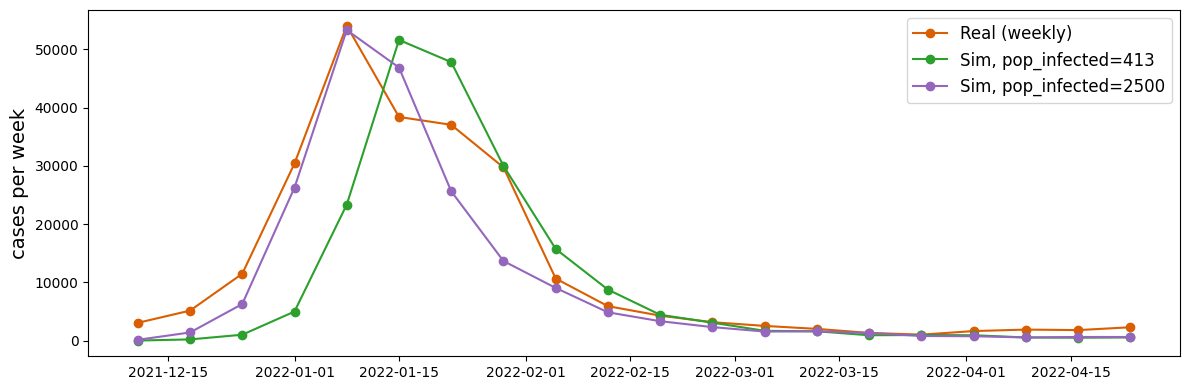

In [78]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(cases_obs.index, cases_obs.values, "o-", color="#D95F02", label="Real (weekly)")

for n_inf, col in [(POP_INFECTED, "tab:green"), (2500, "tab:purple")]:
    s = run_sim(beta=0.18, symp_prob=0.05, pop_infected=n_inf, immune_frac=0.7)
    sim_wk = pd.Series(weekly_sim(s, df_fit), index=cases_obs.index)
    ax.plot(sim_wk.index, sim_wk.values, "o-", color=col, label=f"Sim, pop_infected={n_inf}")

ax.set_ylabel("cases per week", fontsize=14)
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()

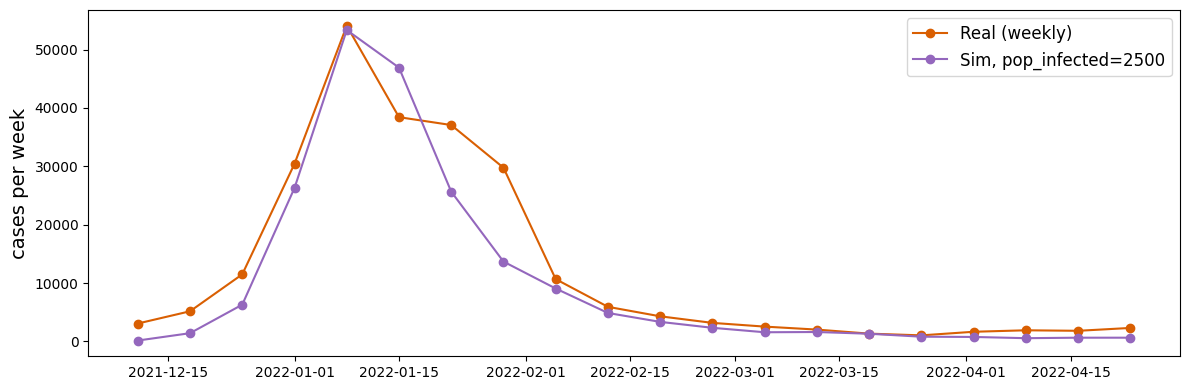

In [79]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(cases_obs.index, cases_obs.values, "o-", color="#D95F02", label="Real (weekly)")

for n_inf, col in [(2500, "tab:purple")]:
    s = run_sim(beta=0.18, symp_prob=0.05, pop_infected=n_inf, immune_frac=0.7)
    sim_wk = pd.Series(weekly_sim(s, df_fit), index=cases_obs.index)
    ax.plot(sim_wk.index, sim_wk.values, "o-", color=col, label=f"Sim, pop_infected={n_inf}")

ax.set_ylabel("cases per week", fontsize=14)
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()

### Wastewater

In [ ]:
d = extract_wastewater_regression_data(s)
d["date"] = pd.to_datetime(d["date"])
sim_ww_daily = d.set_index("date")["wastewater"]

# Sim on the real sample dates, rescaled by the best-fit constant (the same one the loss removes)
sim_ww = sim_ww_daily.reindex(ww_fit.index)
eps = 1e-3 * sim_ww.max() + 1e-12
scale = np.exp(np.mean(np.log(ww_fit.values) - np.log(sim_ww.values + eps)))

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(ww_fit.index, ww_fit.values, ".", ms=8, color="tab:blue", label="Real")
ax.plot(sim_ww_daily.index, (sim_ww_daily + eps) * scale, "-", color="tab:purple", label="Sim (rescaled)")
ax.set_ylabel("copies / L", fontsize=14)
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()

## Part 3: Optuna again

In [ ]:
SIM_START   = pd.Timestamp("2021-11-24")   # sim warms up for 2 weeks
SCORE_START = pd.Timestamp("2021-12-08")   # scoring begins here

df_fit = df_omc[df_omc["week_start"] >= SCORE_START].reset_index(drop=True)
cases_obs = df_fit.set_index("week_mid")["weekly_total"].astype(float)
ww_fit = (ww_omc[ww_omc["Sample_Date"] >= SCORE_START]
            .set_index("Sample_Date")["ww_copies_per_L"].sort_index())
print(len(cases_obs), len(ww_fit))

In [ ]:
def objective(trial):
    beta         = trial.suggest_float("beta", 0.08, 0.25)
    symp_prob    = trial.suggest_float("symp_prob", 0.01, 0.3, log=True)
    pop_infected = trial.suggest_int("pop_infected", 200, 3000, log=True)
    immune_frac  = trial.suggest_float("immune_frac", 0.5, 0.8)

    sim_wk, sim_ww = sim_outputs(beta, symp_prob, pop_infected, immune_frac)

    if sim_wk.sum() < 1 or sim_ww.notna().sum() == 0 or sim_ww.max() <= 0:
        return 10.0

    loss_c, loss_w = compute_loss(sim_wk, sim_ww)
    trial.set_user_attr("loss_cases", float(loss_c))
    trial.set_user_attr("loss_ww", float(loss_w))
    return loss_c + W_WW * loss_w

In [ ]:
study3 = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=42))
study3.enqueue_trial({"beta": 0.18, "symp_prob": 0.05, "pop_infected": 2500, "immune_frac": 0.7})
study3.optimize(objective, n_trials=100, show_progress_bar=True)
print(study3.best_params, study3.best_value)
print(study3.best_trial.user_attrs)

### Best fit

In [ ]:
   print(study3.best_params)
   print(study3.best_trial.user_attrs)
   print("Fit 3 (trial 0):", study3.trials[0].value, study3.trials[0].user_attrs)

{'beta': 0.18259837529898848, 'symp_prob': 0.06312866052882372, 'pop_infected': 227, 'immune_frac': 0.6755786853082207}
{'loss_cases': 0.5053721011927973, 'loss_ww': 0.6160777223796299}
Fit 3 (trial 0): 2.2314181650551044 {'loss_cases': 1.1774756284344894, 'loss_ww': 1.053942536620615}

In [ ]:
   tdf = study3.trials_dataframe()
   print(tdf.nsmallest(10, "value")[["number", "value", "params_beta", "params_symp_prob", "params_pop_infected", "params_immune_frac"]])

In [ ]:
   bp = study3.best_params
   sim_wk, sim_ww = sim_outputs(bp["beta"], bp["symp_prob"], bp["pop_infected"], bp["immune_frac"], n_seeds=5)

In [ ]:
# ---- Plot (instant: reuses sim_wk and sim_ww) ----
# Wastewater: daily sim curve from one seed, plus the 5-seed mean on the real sample dates for the scale constant
eps = 1e-3 * sim_ww.max() + 1e-12
scale = np.exp(np.mean(np.log(ww_fit.values) - np.log(sim_ww.values + eps)))

s = run_sim(bp["beta"], bp["symp_prob"], bp["pop_infected"], bp["immune_frac"], seed=0)
d = extract_wastewater_regression_data(s)
d["date"] = pd.to_datetime(d["date"])
sim_ww_daily = d.set_index("date")["wastewater"]

title = (f"beta={bp['beta']:.3f}, symp_prob={bp['symp_prob']:.3f}, "
         f"pop_infected={bp['pop_infected']}, immune_frac={bp['immune_frac']:.3f}")

fig, ax = plt.subplots(1, 2, figsize=(15, 4))

# Weekly cases
ax[0].plot(cases_obs.index, cases_obs.values, "o-", color="#D95F02", label="Real (weekly)")
ax[0].plot(sim_wk.index, sim_wk.values, "o-", color="tab:green", label="Sim (best fit, 5 seeds)")
ax[0].set_ylabel("cases per week", fontsize=14)
ax[0].set_title(title, fontsize=10)
ax[0].legend(fontsize=11)

# Wastewater (sim rescaled by one constant: timing and shape only)
ax[1].plot(ww_fit.index, ww_fit.values, ".", ms=8, color="tab:blue", label="Real")
ax[1].plot(sim_ww_daily.index, (sim_ww_daily + eps) * scale, "-", color="tab:green",
           label="Sim (rescaled)")
ax[1].set_xlim(ww_fit.index.min() - pd.Timedelta(days=3), ww_fit.index.max() + pd.Timedelta(days=3))
ax[1].set_ylabel("copies / L", fontsize=14)
ax[1].legend(fontsize=11)

plt.tight_layout()
plt.show()

### Replicate the best findings

In [ ]:
bp = {"beta": 0.1826, "symp_prob": 0.0631, "pop_infected": 227, "immune_frac": 0.6756}

sim_wk, sim_ww = sim_outputs(bp["beta"], bp["symp_prob"], bp["pop_infected"],
                             bp["immune_frac"], n_seeds=5)
print(compute_loss(sim_wk, sim_ww))   # expect roughly (0.5, 0.6)